# Grad-CAM complet pour MedVision

**Auteur :** Yann Smatti  

Ce notebook montre un **pipeline complet Grad-CAM** avec TensorFlow/Keras, dans un esprit compatible avec le projet **MedVision** :

1. chargement d'un modèle CNN ou transfert learning,
2. préparation d'une image médicale,
3. prédiction,
4. récupération de la dernière couche convolutionnelle,
5. calcul de la heatmap Grad-CAM,
6. superposition avec l'image originale,
7. fonctions réutilisables pour ton projet.

Le notebook contient aussi des explications pédagogiques pour bien comprendre le rôle de chaque étape.


## Rappel intuitif

Grad-CAM cherche à répondre à la question :

> **Quelles zones de l'image ont contribué positivement à la prédiction d'une classe ?**

Mathématiquement, on prend :
- les **feature maps** de la dernière couche convolutionnelle ;
- les **gradients du score de classe** par rapport à ces feature maps ;
- puis on combine ces cartes avec des poids moyens.

Formule centrale :

$
\alpha_k^c = \frac{1}{Z}\sum_{i,j}\frac{\partial y^c}{\partial A_{ij}^k},
\qquad
L^c = ReLU\left(\sum_k \alpha_k^c A^k\right)
$


In [1]:
# Si nécessaire, décommenter la ligne suivante dans un environnement vierge.
# !pip install tensorflow pillow matplotlib numpy


In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras


## Configuration


In [3]:
IMAGE_SIZE = (224, 224)
CLASS_NAMES = ["normal", "pathology"]  # à adapter à ton dataset
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


## Option A — construire un petit modèle de démonstration

Cette cellule crée un petit CNN pour que le notebook reste autonome.
Dans mon projet MedVision, je remplacerai ensuite ce modèle par mon modèle entraîné.


In [4]:
def build_demo_model(input_shape=(224, 224, 3), n_classes=2):
    inputs = keras.Input(shape=input_shape)

    x = keras.layers.Conv2D(16, 3, activation="relu", padding="same", name="conv1")(inputs)
    x = keras.layers.MaxPooling2D()(x)

    x = keras.layers.Conv2D(32, 3, activation="relu", padding="same", name="conv2")(x)
    x = keras.layers.MaxPooling2D()(x)

    x = keras.layers.Conv2D(64, 3, activation="relu", padding="same", name="last_conv")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    x = keras.layers.Dense(32, activation="relu")(x)
    outputs = keras.layers.Dense(n_classes, activation=None, name="logits")(x)

    model = keras.Model(inputs, outputs, name="medvision_demo_cnn")
    return model

model = build_demo_model(input_shape=(*IMAGE_SIZE, 3), n_classes=len(CLASS_NAMES))
model.summary()


Model: "medvision_demo_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,730 (100.51 KB)

 Trainable params: 25,730 (100.51 KB)

 Non-trainable params: 0 (0.00 B)

## Option B — charger mon vrai modèle MedVision

Quand j'aurai un vrai modèle entraîné, je pourrai remplacer la cellule précédente par quelque chose comme :

```python
model = keras.models.load_model("models/medvision_model.keras")
```

Dans tous les cas, il faudra indiquer le nom de la **dernière couche convolutionnelle**.


In [5]:
LAST_CONV_LAYER_NAME = "last_conv"


## Préparation de l'image


In [6]:
def load_image_for_model(image_path, image_size=(224, 224)):
    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize(image_size)

    image_array = np.asarray(image_resized).astype("float32") / 255.0
    image_batch = np.expand_dims(image_array, axis=0)

    return image, image_resized, image_array, image_batch


## Créer une image jouet si je n'ai pas encore d'image médicale


In [9]:
demo_image_path = Path("../data/raw/chest_xray/train/PNEUMONIA/person1_bacteria_1.jpeg")  # à adapter à ton dataset

if not demo_image_path.exists():
    arr = np.zeros((224, 224, 3), dtype=np.uint8)
    arr[..., 1] = 30
    arr[..., 2] = 30

    yy, xx = np.ogrid[:224, :224]
    mask = (yy - 112) ** 2 + (xx - 112) ** 2 <= 35 ** 2
    arr[mask, 0] = 220
    arr[mask, 1] = 60
    arr[mask, 2] = 60

    Image.fromarray(arr).save(demo_image_path)

demo_image_path


WindowsPath('../data/raw/chest_xray/train/PNEUMONIA/person1_bacteria_1.jpeg')

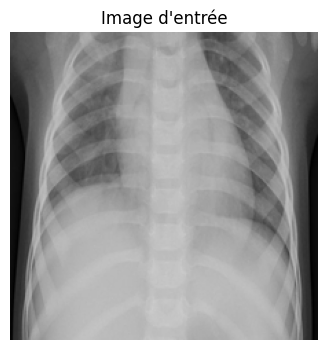

In [10]:
image_path = demo_image_path  # remplace par ton image médicale

orig_pil, resized_pil, image_array, image_batch = load_image_for_model(
    image_path=image_path,
    image_size=IMAGE_SIZE
)

plt.figure(figsize=(4, 4))
plt.imshow(resized_pil)
plt.title("Image d'entrée")
plt.axis("off")
plt.show()


## Prédiction du modèle


In [11]:
logits = model.predict(image_batch, verbose=0)
probs = tf.nn.softmax(logits, axis=-1).numpy()[0]

pred_class_index = int(np.argmax(probs))
pred_class_name = CLASS_NAMES[pred_class_index]
pred_confidence = float(probs[pred_class_index])

print("Probabilités :", {name: float(p) for name, p in zip(CLASS_NAMES, probs)})
print("Classe prédite :", pred_class_name)
print("Confiance :", round(pred_confidence, 4))


Probabilités : {'normal': 0.47316354513168335, 'pathology': 0.5268365144729614}
Classe prédite : pathology
Confiance : 0.5268


## Modèle auxiliaire pour Grad-CAM


In [12]:
grad_model = keras.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(LAST_CONV_LAYER_NAME).output,
        model.output,
    ],
    name="gradcam_model"
)

grad_model


<Functional name=gradcam_model, built=True>

## Fonction complète de calcul de Grad-CAM


In [13]:
def make_gradcam_heatmap(
    image_batch,
    model,
    last_conv_layer_name,
    class_index=None
):
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output,
        ],
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(image_batch, training=False)

        if class_index is None:
            class_index = tf.argmax(preds[0])

        class_channel = preds[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    denom = tf.reduce_max(heatmap)
    if float(denom) > 0:
        heatmap = heatmap / denom

    return heatmap.numpy()


Shape heatmap : (56, 56)


c:\Users\smatt\Documents\Github\medvision-ai\.venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


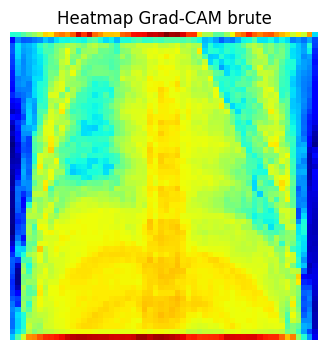

In [14]:
heatmap = make_gradcam_heatmap(
    image_batch=image_batch,
    model=model,
    last_conv_layer_name=LAST_CONV_LAYER_NAME,
    class_index=pred_class_index
)

print("Shape heatmap :", heatmap.shape)

plt.figure(figsize=(4, 4))
plt.imshow(heatmap, cmap="jet")
plt.title("Heatmap Grad-CAM brute")
plt.axis("off")
plt.show()


## Superposition de la heatmap à l'image originale


In [15]:
def overlay_gradcam(
    image_array,
    heatmap,
    alpha=0.4,
    cmap="jet"
):
    h, w = image_array.shape[:2]
    heatmap_uint8 = np.uint8(255 * heatmap)

    cmap_obj = plt.get_cmap(cmap)
    colored = cmap_obj(np.arange(256))[:, :3]
    colored_heatmap = colored[heatmap_uint8]

    colored_heatmap = tf.image.resize(colored_heatmap, (h, w)).numpy()

    overlay = (1 - alpha) * image_array + alpha * colored_heatmap
    overlay = np.clip(overlay, 0, 1)

    return colored_heatmap, overlay


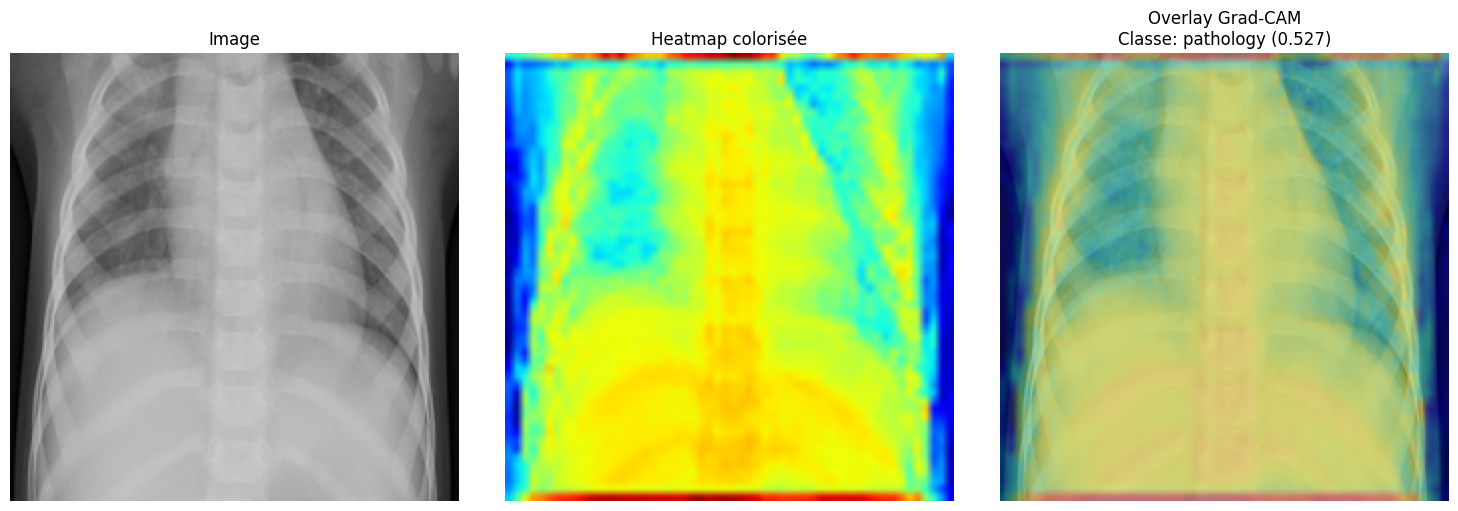

In [16]:
colored_heatmap, overlay = overlay_gradcam(
    image_array=image_array,
    heatmap=heatmap,
    alpha=0.4,
    cmap="jet"
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_array)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(colored_heatmap)
axes[1].set_title("Heatmap colorisée")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"Overlay Grad-CAM\nClasse: {pred_class_name} ({pred_confidence:.3f})")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Interprétation de la heatmap

Quand je lis une heatmap Grad-CAM, je me demande toujours :

1. La zone chaude est-elle médicalement pertinente ?
2. Le modèle regarde-t-il un artefact ?
3. La heatmap est-elle bien localisée ou diffuse ?
4. Le comportement est-il cohérent sur plusieurs images ?


## Variante : choisir une autre classe cible


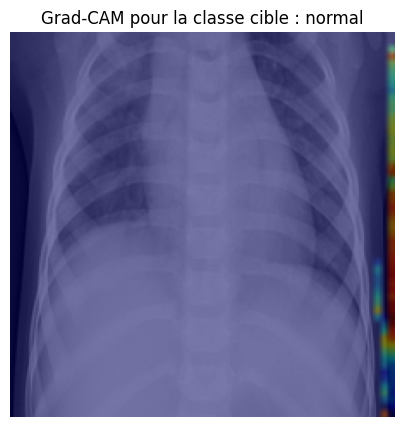

In [17]:
target_class_index = 0

heatmap_target = make_gradcam_heatmap(
    image_batch=image_batch,
    model=model,
    last_conv_layer_name=LAST_CONV_LAYER_NAME,
    class_index=target_class_index
)

_, overlay_target = overlay_gradcam(
    image_array=image_array,
    heatmap=heatmap_target,
    alpha=0.4,
    cmap="jet"
)

plt.figure(figsize=(5, 5))
plt.imshow(overlay_target)
plt.title(f"Grad-CAM pour la classe cible : {CLASS_NAMES[target_class_index]}")
plt.axis("off")
plt.show()


## Sauvegarder les résultats


In [18]:
output_dir = Path("/mnt/data/gradcam_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

overlay_path = output_dir / "gradcam_overlay.png"
heatmap_path = output_dir / "gradcam_heatmap.png"

Image.fromarray((overlay * 255).astype(np.uint8)).save(overlay_path)
Image.fromarray((colored_heatmap * 255).astype(np.uint8)).save(heatmap_path)

print("Overlay sauvegardé :", overlay_path)
print("Heatmap sauvegardée :", heatmap_path)


Overlay sauvegardé : \mnt\data\gradcam_outputs\gradcam_overlay.png
Heatmap sauvegardée : \mnt\data\gradcam_outputs\gradcam_heatmap.png


## Version réutilisable pour MedVision


In [19]:
def run_gradcam_pipeline(
    image_path,
    model,
    last_conv_layer_name,
    class_names,
    image_size=(224, 224),
    alpha=0.4,
    class_index=None,
):
    orig_pil, resized_pil, image_array, image_batch = load_image_for_model(
        image_path=image_path,
        image_size=image_size,
    )

    logits = model.predict(image_batch, verbose=0)
    probs = tf.nn.softmax(logits, axis=-1).numpy()[0]

    pred_class_index = int(np.argmax(probs))
    pred_class_name = class_names[pred_class_index]
    pred_confidence = float(probs[pred_class_index])

    if class_index is None:
        class_index = pred_class_index

    heatmap = make_gradcam_heatmap(
        image_batch=image_batch,
        model=model,
        last_conv_layer_name=last_conv_layer_name,
        class_index=class_index,
    )

    colored_heatmap, overlay = overlay_gradcam(
        image_array=image_array,
        heatmap=heatmap,
        alpha=alpha,
        cmap="jet",
    )

    result = {
        "orig_pil": orig_pil,
        "resized_pil": resized_pil,
        "image_array": image_array,
        "probs": probs,
        "pred_class_index": pred_class_index,
        "pred_class_name": pred_class_name,
        "pred_confidence": pred_confidence,
        "target_class_index": class_index,
        "target_class_name": class_names[class_index],
        "heatmap": heatmap,
        "colored_heatmap": colored_heatmap,
        "overlay": overlay,
    }
    return result


Classe prédite : pathology
Classe expliquée : pathology
Confiance : 0.5268


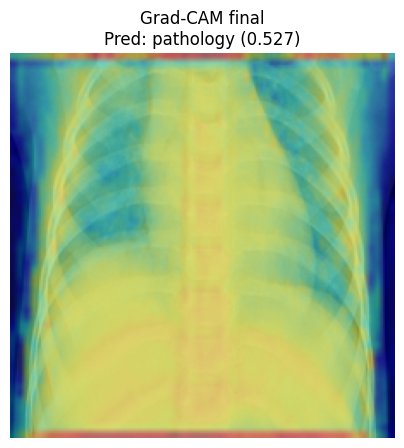

In [20]:
result = run_gradcam_pipeline(
    image_path=image_path,
    model=model,
    last_conv_layer_name=LAST_CONV_LAYER_NAME,
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    alpha=0.45,
)

print("Classe prédite :", result["pred_class_name"])
print("Classe expliquée :", result["target_class_name"])
print("Confiance :", round(result["pred_confidence"], 4))

plt.figure(figsize=(5, 5))
plt.imshow(result["overlay"])
plt.title(
    f"Grad-CAM final\nPred: {result['pred_class_name']} ({result['pred_confidence']:.3f})"
)
plt.axis("off")
plt.show()


## Aller plus loin dans MedVision

Dans mon vrai projet, je peux :

1. utiliser mon vrai modèle :
```python
model = keras.models.load_model("models/medvision_best.keras")
```

2. boucler sur un dossier test pour générer automatiquement une heatmap par image ;

3. intégrer dans FastAPI ou Streamlit ;

4. comparer plusieurs couches convolutionnelles.


## Pièges fréquents

1. Mauvaise dernière couche convolutionnelle  
2. Utiliser la mauvaise sortie (probabilités au lieu des logits, selon le cas)  
3. Heatmap très diffuse  
4. Heatmap jolie mais trompeuse

Une heatmap n'est pas une preuve clinique : c'est un outil d'analyse.


## Résumé

Ce notebook me donne un pipeline complet :

- modèle TensorFlow/Keras,
- préparation image,
- prédiction,
- calcul Grad-CAM,
- overlay,
- fonction réutilisable pour MedVision.

Je peux maintenant brancher mon vrai modèle et mon vrai dataset.
